In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import percentileofscore

In [2]:
savefig = True

water_year_start, water_year_end = ("2022-04-01", "2023-03-31")
twenty_years_start, twenty_years_end = ("2003-04-01", "2023-03-31")


datapath = Path("../data/unscaled_flow.csv")
figpath =  Path("../results")

rivers = ['Yelcho', 'Puelo', 'Palena', 'Cisnes', 'Aysen']

In [3]:
flow_data = pd.read_csv(datapath).set_index("Date")
flow_data.index = pd.to_datetime(flow_data.index)

In [4]:
fd20 = flow_data[twenty_years_start:twenty_years_end]
fd1 = flow_data[water_year_start:water_year_end]

In [5]:
water_years = pd.Series(2003, index=fd20.index)
year=2003
apr1date = pd.Timestamp(year=year, month=4, day=1)
while fd20.index[-1] >= apr1date:
    year += 1
    apr1date = pd.Timestamp(year=year, month=4, day=1)
    water_years += (fd20.index >= apr1date)

In [6]:
percentile = lambda a, b: (a >= b).mean()

In [8]:
fd20_gb = fd20.groupby(water_years)

# Red text (annual flow percentiles)
print("I think this is the stuff described in the red text")
pd.DataFrame(
    [
        percentile(fd1.sum(), fd20_gb.sum()),
        percentile(fd1.max(), fd20_gb.max()),
        percentile(fd1.min(), fd20_gb.min())
    ],
    index=["Annual", "Maxes", "Mins"]
).transpose()

I think this is the stuff described in the red text


,Annual,Maxes,Mins
Aysen,0.25,0.75,0.60
Cisnes,0.55,0.65,0.80
Palena,0.25,0.30,0.40
Puelo,0.35,0.10,0.55
Yelcho,0.40,0.20,0.75


In [10]:
quantiles20y = fd20.quantile([0.1, 0.5, 0.9])
print("10th percentile, 50th percentile, 90th percentile")
pd.DataFrame(
    quantiles20y.transpose().apply(lambda qt: (fd1 <= qt).mean()),
    #columns=quantiles.index.astype("str")+"th"
)

10th percentile, 50th percentile, 90th percentile


,0.1,0.5,0.9
Aysen,0.169863,0.668493,0.939726
Cisnes,0.049315,0.435616,0.909589
Palena,0.178082,0.564384,0.915068
Puelo,0.123288,0.484932,0.942466
Yelcho,0.065753,0.493151,0.942466


In [11]:
quantiles20y.loc[0.9]

Aysen      867.7952
Cisnes     389.6632
Palena    1390.2000
Puelo     1088.5316
Yelcho     610.6120
Name: 0.9, dtype: float64

In [20]:
# Count number of "floods (80%ile and 5 days)"
days_cutoff = 5
above80th = (fd1 >= quantiles20y.quantile(0.8))
#(above90th > above90th.shift(1, fill_value=False)).sum()
floods_filtered = pd.concat(
    [pd.DataFrame(data=False, index=[0], columns=above80th.columns), above80th] # for ffill
).replace({True: pd.NA}).ffill(limit=days_cutoff).fillna(True)
floods_filtered = floods_filtered.replace({False: pd.NA}).bfill(limit=days_cutoff).fillna(False) # Restore the last 5 days
floods_filtered = floods_filtered.iloc[1:] # get rid of that row from 2 lines ago
(floods_filtered > floods_filtered.shift(1, fill_value=False)).sum()

C:\Users\foxni\AppData\Local\Temp\ipykernel_24180\750575970.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({True: pd.NA}).ffill(limit=days_cutoff).fillna(True)
C:\Users\foxni\AppData\Local\Temp\ipykernel_24180\750575970.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  floods_filtered = floods_filtered.replace({False: pd.NA}).bfill(limit=days_cutoff).fillna(False) # Restore the last 5 days


Aysen     1
Cisnes    2
Palena    4
Puelo     4
Yelcho    3
dtype: int64

In [21]:
# Count number of "droughts"
below10th = (fd1 >= quantiles20y.loc[0.9])
#(above90th > above90th.shift(1, fill_value=False)).sum()
droughts_filtered = pd.concat(
    [pd.DataFrame(data=False, index=[0], columns=below10th.columns), below10th]
).replace({True: pd.NA}).ffill(limit=13).fillna(True)
(droughts_filtered > droughts_filtered.shift(1, fill_value=False)).sum()

C:\Users\foxni\AppData\Local\Temp\ipykernel_24180\3389163688.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({True: pd.NA}).ffill(limit=13).fillna(True)


Aysen     0
Cisnes    0
Palena    0
Puelo     0
Yelcho    0
dtype: int64

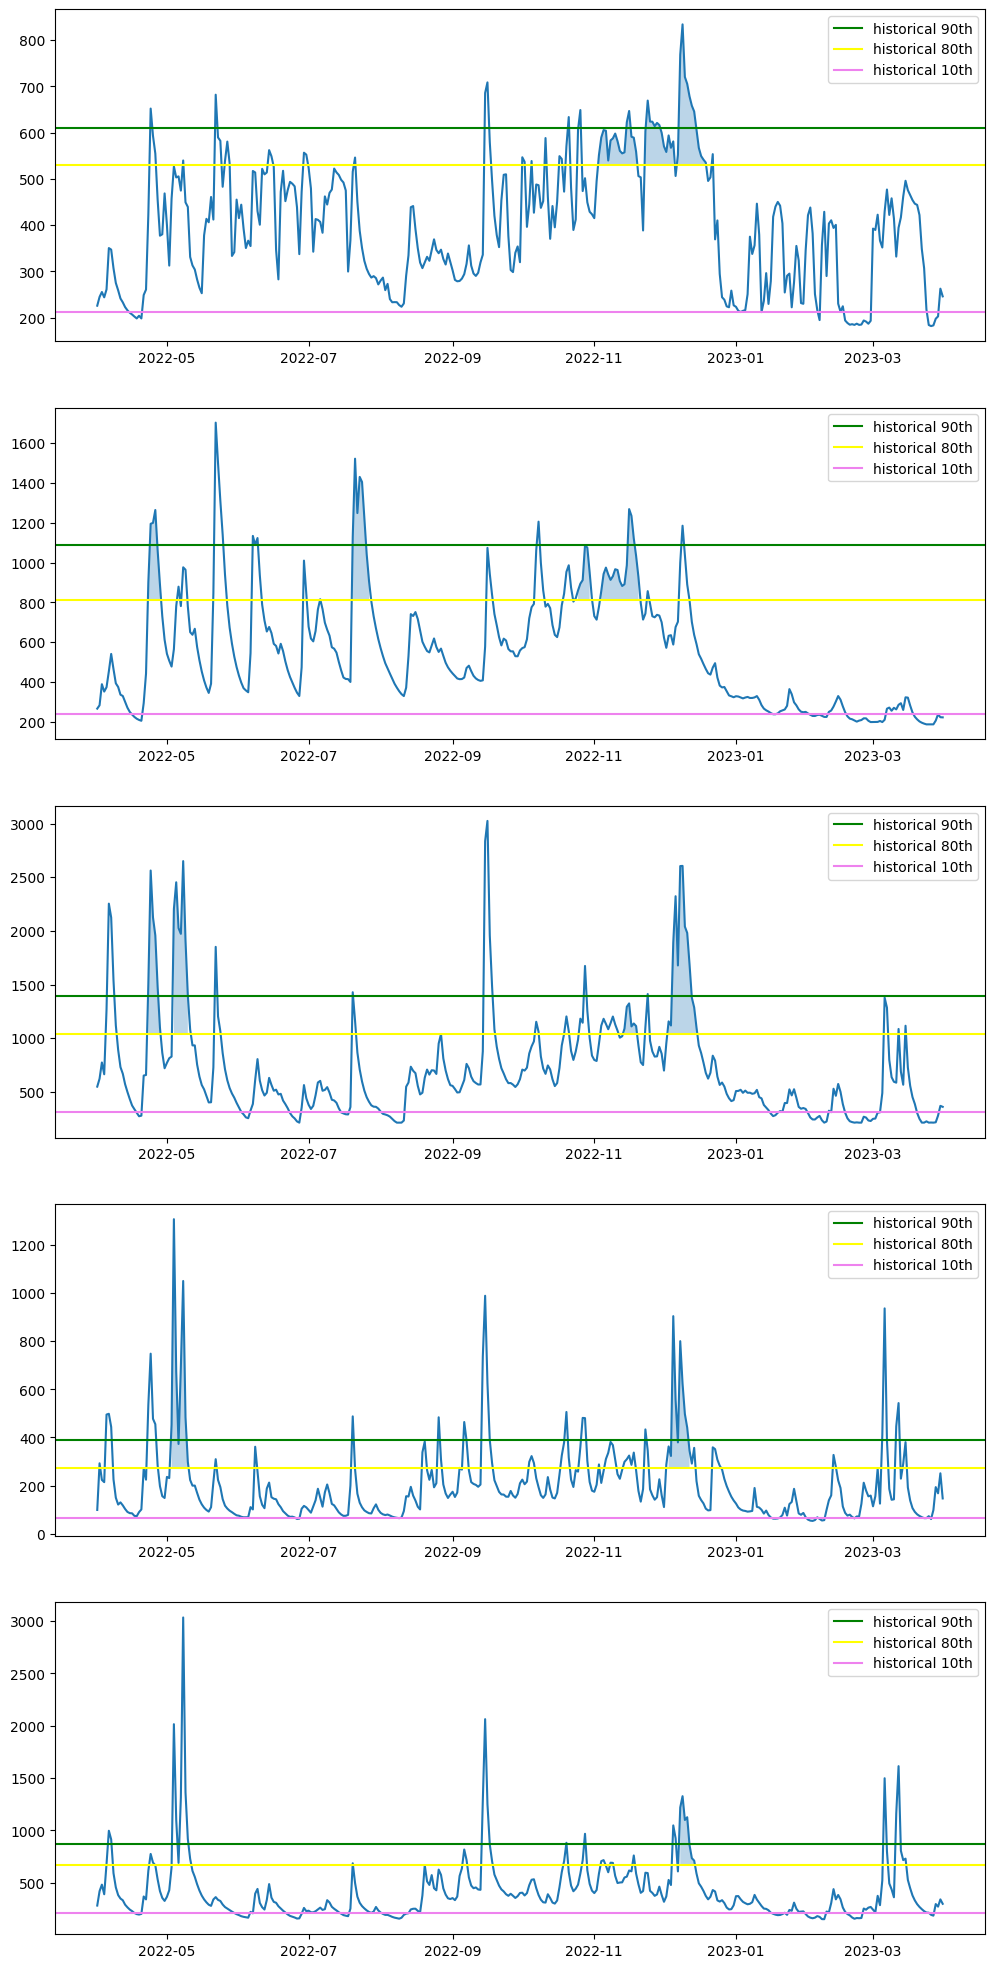

In [23]:
fig, axes = plt.subplots(figsize=(12, 5*len(rivers)), nrows=len(rivers))

for riv, ax in zip(rivers, axes):
    ax.plot(fd1[riv])
    ax.axhline(fd20[riv].quantile(0.9), color="green", label="historical 90th")
    ax.axhline(fd20[riv].quantile(0.8), color="yellow", label="historical 80th")
    ax.axhline(fd20[riv].quantile(0.1), color="violet", label="historical 10th")
    floodvals = fd1[riv].where(floods_filtered[riv], other=pd.NA)
    ax.fill_between(x=floodvals.index, y1=floodvals, y2=fd20[riv].quantile(0.8), alpha=0.3)
    ax.legend()

In [19]:
(floods_filtered > floods_filtered.shift(1, fill_value=False)).iloc[1:]

,Aysen,Cisnes,Palena,Puelo,Yelcho
2022-04-02 00:00:00,False,False,False,False,False
2022-04-03 00:00:00,False,False,False,False,False
2022-04-04 00:00:00,False,False,False,False,False
2022-04-05 00:00:00,False,True,True,False,False
2022-04-06 00:00:00,False,False,False,False,False
...,...,...,...,...,...
2023-03-27 00:00:00,False,False,False,False,False
2023-03-28 00:00:00,False,False,False,False,False
2023-03-29 00:00:00,False,False,False,False,False
2023-03-30 00:00:00,False,False,False,False,False


In [52]:
fd1_qs = pd.DataFrame(
    data=[percentileofscore(fd20[riv], fd1[riv]) for riv in fd1.columns],
    index=fd1.columns
).transpose()

# Mean 20y percentiles
fd1_qs.agg(["mean", "median"]) # No mode

,Aysen,Cisnes,Palena,Puelo,Yelcho
mean,39.383440,53.208386,45.343253,49.407162,50.145031
median,33.566051,54.551677,42.737851,53.744011,51.115674


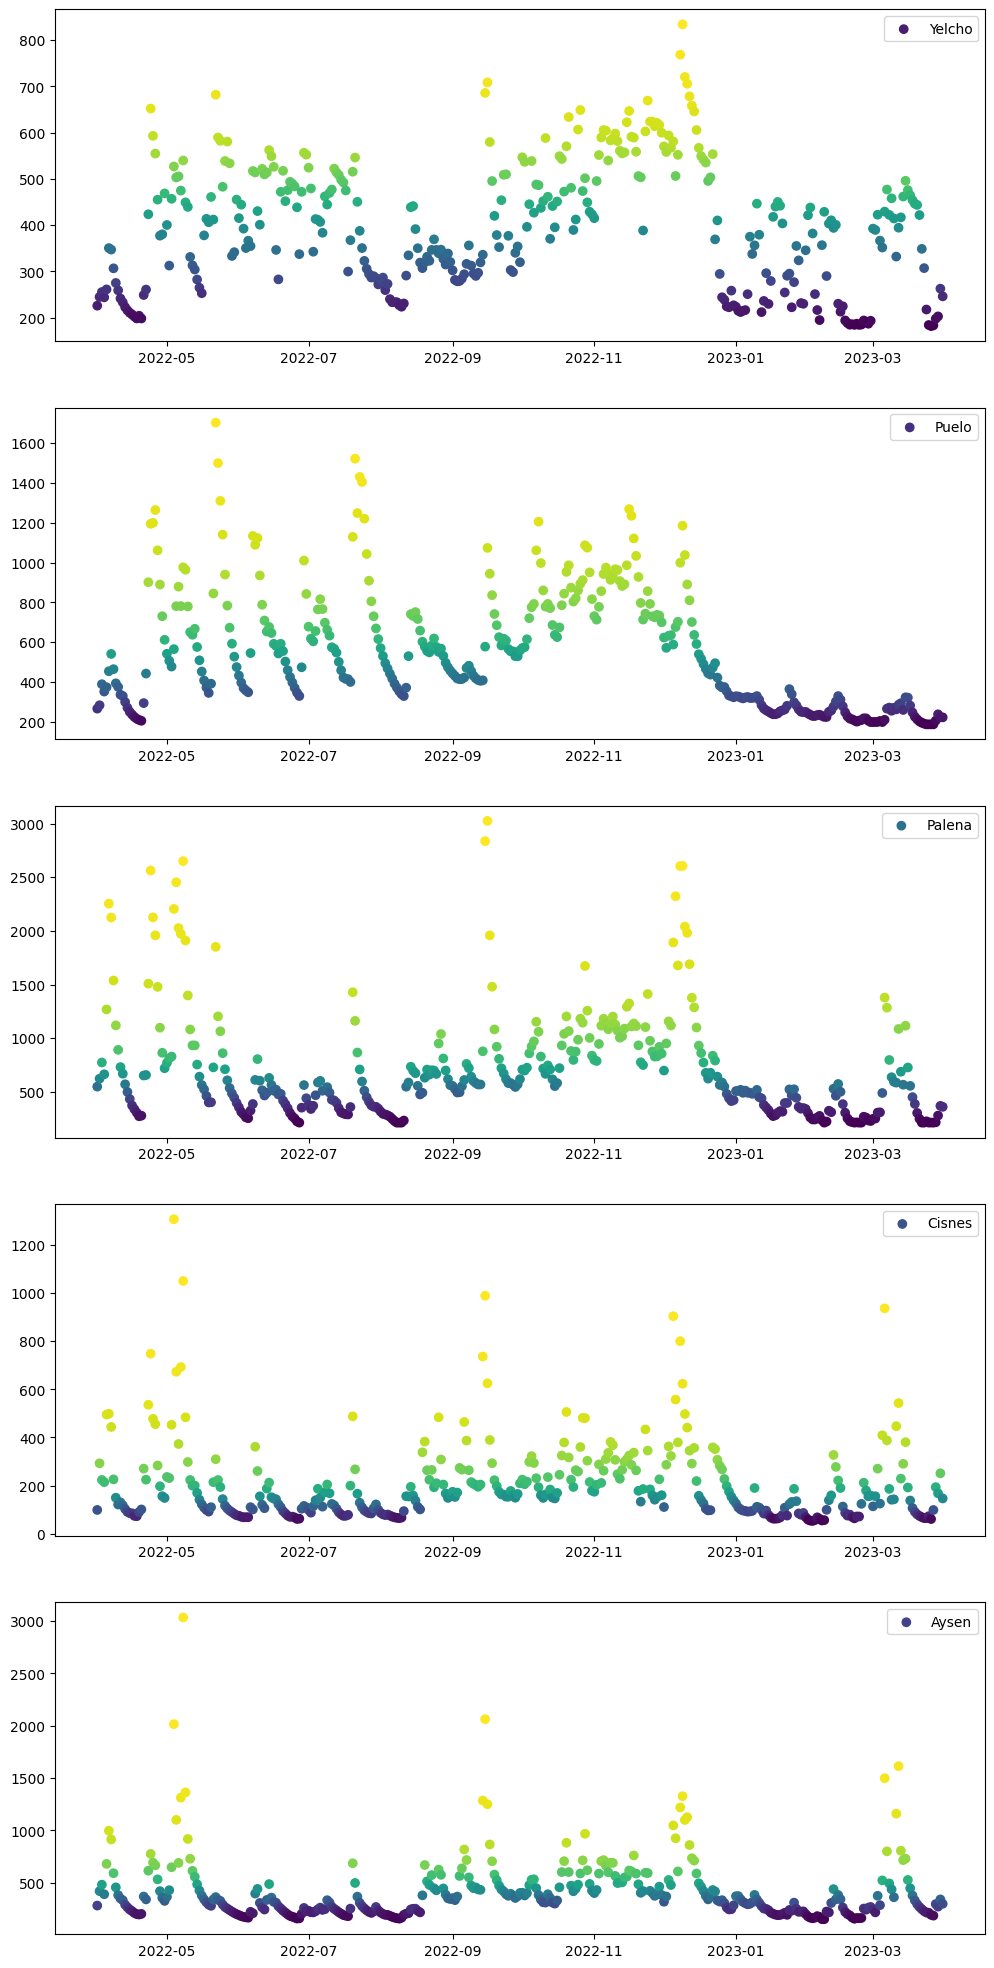

In [46]:
fig, axes = plt.subplots(figsize=(12, 5*len(rivers)), nrows=len(rivers))

for riv, ax in zip(rivers, axes):
    # sns.lineplot(
    #     data=fd1,
    #     x=fd1.index,
    #     y=riv,
    #     hue=fd1_qs[riv],
    #     palette="viridis",
    #     ax=ax
    # )
    ax.scatter(
        fd1.index,
        fd1[riv],
        c=fd1_qs[riv],
        cmap="viridis",
        label=riv
    )
    ax.legend()

In [38]:
len(fd1_qs[riv])

365